# Stage-Flag Two-Qubit Sweep Plots

Compare scenario-specific sweep folders such as state-prep-only, TCNOT-only, swap-only, and all-2q-noise runs. The notebook loads the newest timestamp cohort from each directory, plots raw/corrected logical infidelity, and fits `A p + B p^2` per scenario.


In [11]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")


In [12]:
BASE_LOG_DIR = Path("/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th")

EXPERIMENTS = [
    {
        "label": "encoder_only",
        "log_dir": BASE_LOG_DIR / "graph_two_qubit_gate_sweep_only_2q_noise_stateprep_Inspection",
    },
    {
        "label": "tcnot_only",
        "log_dir": BASE_LOG_DIR / "graph_two_qubit_gate_sweep_only_2q_noise_tcnot_Inspection",
    },
    {
        "label": "swap_only",
        "log_dir": BASE_LOG_DIR / "graph_two_qubit_gate_sweep_only_2q_noise_swap_Inspection",
    },
    {
        "label": "all_2q",
        "log_dir": BASE_LOG_DIR / "graph_two_qubit_gate_sweep_only_2q_noise",
    },
]

EXPERIMENTS


[{'label': 'encoder_only',
  'log_dir': PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th/graph_two_qubit_gate_sweep_only_2q_noise_stateprep_Inspection')},
 {'label': 'tcnot_only',
  'log_dir': PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th/graph_two_qubit_gate_sweep_only_2q_noise_tcnot_Inspection')},
 {'label': 'swap_only',
  'log_dir': PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th/graph_two_qubit_gate_sweep_only_2q_noise_swap_Inspection')},
 {'label': 'all_2q',
  'log_dir': PosixPath('/Users/patange/Documents/Argonne/QEC/log/runner_test_april29th/graph_two_qubit_gate_sweep_only_2q_noise')}]

In [13]:
filename_re = re.compile(
    r"line_(?P<nodes>\d+)_2G,"
    r"code=(?P<code>\[\[.*?\]\]),"
    r"dist=(?P<dist>[0-9.]+),"
    r"gate=(?P<gate>[0-9.]+),"
    r"twoq=(?P<twoq>[0-9.]+),"
    r"meas=(?P<meas>[0-9.]+|cfg),"
    r"prep=(?P<prep>[0-9.]+),"
    r"T1=(?P<t1>[0-9.eE+-]+),"
    r"T2=(?P<t2>[0-9.eE+-]+),"
    r"ft=(?P<ft>[a-zA-Z0-9_]+),"
    r"pauli=(?P<pauli>[0-9._]+|cfg),"
    r"ccorr=(?P<ccorr>none|cec|qec\+cec|qec),"
    r"physbell=(?P<physbell>[0-9.]+|cfg),"
    r"ts=(?P<ts>\d{8}_\d{6})"
)

critical_e2e_re = re.compile(
    r"critical_e2e run_id=(?P<run_id>\d+) "
    r"latency_ps=(?P<latency_ps>[-+0-9.eE]+|None) "
    r"fidelity_raw=(?P<fidelity_raw>[-+0-9.eE]+|None) "
    r"fidelity_corrected=(?P<fidelity_corrected>[-+0-9.eE]+|None) "
    r"fidelity_delta=(?P<fidelity_delta>[-+0-9.eE]+|None)"
)

critical_noise_re = re.compile(
    r"critical_noise run_id=(?P<run_id>\d+) "
    r".*?gate_2q_by_block_pair=(?P<gate_2q_by_block_pair>\{.*?\}) "
    r"gate_2q_attempts_by_block_pair=(?P<gate_2q_attempts_by_block_pair>\{.*?\}) "
    r"gate_2q_observed_rate_by_block_pair=(?P<gate_2q_observed_rate_by_block_pair>\{.*?\}) "
    r"measurement_by_block="
)


In [14]:
def newest_timestamp_files(log_dir: Path) -> list[Path]:
    """Return files from the newest timestamp cohort in one log directory.

    Args:
        log_dir: Directory containing one sweep's log files.

    Returns:
        list[Path]: Sorted files from the newest timestamp cohort.
    """
    if not log_dir.exists():
        return []

    files = sorted(
        [path for path in log_dir.iterdir() if path.is_file()],
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not files:
        return []

    latest_match = filename_re.search(files[0].name)
    if latest_match is None:
        return []
    latest_ts = latest_match.group("ts")
    return sorted([path for path in files if f"ts={latest_ts}" in path.name])


def load_experiment_runs(label: str, log_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Load run-level fidelity and optional 2q-noise summaries for one scenario.

    Args:
        label: Scenario label for this directory.
        log_dir: Directory containing one sweep cohort.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: Run-level E2E rows and 2q-noise rows.
    """
    e2e_rows: list[dict[str, object]] = []
    noise_rows: list[dict[str, object]] = []

    for path in newest_timestamp_files(log_dir):
        meta_match = filename_re.search(path.name)
        if meta_match is None:
            continue
        meta = meta_match.groupdict()
        twoq = float(meta["twoq"])
        cohort_ts = str(meta["ts"])

        with path.open("r", encoding="utf-8") as handle:
            for line in handle:
                e2e_match = critical_e2e_re.search(line)
                if e2e_match is not None:
                    latency_raw = e2e_match.group("latency_ps")
                    fidelity_raw = e2e_match.group("fidelity_raw")
                    fidelity_corrected = e2e_match.group("fidelity_corrected")
                    e2e_rows.append(
                        {
                            "label": label,
                            "cohort_ts": cohort_ts,
                            "log_name": path.name,
                            "two_qubit_gate_fidelity": twoq,
                            "run_id": int(e2e_match.group("run_id")),
                            "latency_ps": np.nan if latency_raw == "None" else float(latency_raw),
                            "fidelity_raw": np.nan if fidelity_raw == "None" else float(fidelity_raw),
                            "fidelity_corrected": np.nan if fidelity_corrected == "None" else float(fidelity_corrected),
                        }
                    )
                    continue

                noise_match = critical_noise_re.search(line)
                if noise_match is None:
                    continue

                error_dict = eval(noise_match.group("gate_2q_by_block_pair"), {"__builtins__": {}}, {})
                attempt_dict = eval(noise_match.group("gate_2q_attempts_by_block_pair"), {"__builtins__": {}}, {})
                noise_rows.append(
                    {
                        "label": label,
                        "cohort_ts": cohort_ts,
                        "log_name": path.name,
                        "two_qubit_gate_fidelity": twoq,
                        "run_id": int(noise_match.group("run_id")),
                        "twoq_attempts": float(sum(attempt_dict.values())),
                        "twoq_errors": float(sum(error_dict.values())),
                        "twoq_error_branches": dict(error_dict),
                        "twoq_attempt_breakdown": dict(attempt_dict),
                    }
                )

    return pd.DataFrame(e2e_rows), pd.DataFrame(noise_rows)


def build_summary(run_df: pd.DataFrame, noise_df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate run-level data into one scenario-by-fidelity summary table.

    Args:
        run_df: Run-level end-to-end fidelity rows.
        noise_df: Run-level 2q-noise rows.

    Returns:
        pd.DataFrame: One row per scenario and sweep point.
    """
    if run_df.empty:
        return pd.DataFrame()

    summary_df = (
        run_df.groupby(["label", "cohort_ts", "two_qubit_gate_fidelity"], as_index=False)
        .agg(
            fidelity_raw=("fidelity_raw", "mean"),
            fidelity_corrected=("fidelity_corrected", "mean"),
            avg_latency_ps=("latency_ps", "mean"),
            run_count=("run_id", "count"),
        )
        .sort_values(["label", "two_qubit_gate_fidelity"])
    )

    if not noise_df.empty:
        noise_summary_df = (
            noise_df.groupby(["label", "cohort_ts", "two_qubit_gate_fidelity"], as_index=False)
            .agg(
                avg_2q_attempts=("twoq_attempts", "mean"),
                avg_2q_errors=("twoq_errors", "mean"),
            )
            .sort_values(["label", "two_qubit_gate_fidelity"])
        )
        summary_df = summary_df.merge(
            noise_summary_df,
            on=["label", "cohort_ts", "two_qubit_gate_fidelity"],
            how="left",
        )

    summary_df["p_2q"] = 1.25 * (1.0 - summary_df["two_qubit_gate_fidelity"])
    summary_df["raw_infidelity"] = 1.0 - summary_df["fidelity_raw"]
    summary_df["corrected_infidelity"] = 1.0 - summary_df["fidelity_corrected"]
    return summary_df


def fit_linear_quadratic(group: pd.DataFrame, y_column: str) -> dict[str, float]:
    """Fit y ~= A p + B p^2 with zero intercept.

    Args:
        group: One scenario summary dataframe.
        y_column: Summary column to fit.

    Returns:
        dict[str, float]: Fitted coefficients and RMSE.
    """
    fit_group = group.dropna(subset=["p_2q", y_column]).copy()
    fit_group = fit_group[fit_group["p_2q"] > 0]
    if fit_group.empty:
        return {"A": np.nan, "B": np.nan, "rmse": np.nan}

    x = fit_group["p_2q"].to_numpy()
    y = fit_group[y_column].to_numpy()
    design = np.column_stack([x, x ** 2])
    coeffs, *_ = np.linalg.lstsq(design, y, rcond=None)
    residual = y - design @ coeffs
    rmse = float(np.sqrt(np.mean(residual ** 2)))
    return {"A": float(coeffs[0]), "B": float(coeffs[1]), "rmse": rmse}


In [15]:
all_run_frames = []
all_noise_frames = []
availability_rows = []

for experiment in EXPERIMENTS:
    run_df, noise_df = load_experiment_runs(experiment["label"], experiment["log_dir"])
    all_run_frames.append(run_df)
    all_noise_frames.append(noise_df)
    availability_rows.append(
        {
            "label": experiment["label"],
            "log_dir": str(experiment["log_dir"]),
            "exists": experiment["log_dir"].exists(),
            "run_rows": int(len(run_df)),
            "noise_rows": int(len(noise_df)),
            "cohort_ts": "" if run_df.empty else str(run_df["cohort_ts"].iloc[0]),
        }
    )

run_df = pd.concat(all_run_frames, ignore_index=True) if all_run_frames else pd.DataFrame()
noise_df = pd.concat(all_noise_frames, ignore_index=True) if all_noise_frames else pd.DataFrame()
availability_df = pd.DataFrame(availability_rows)
summary_df = build_summary(run_df, noise_df)

availability_df


,label,log_dir,exists,run_rows,noise_rows,cohort_ts
0,encoder_only,/Users/patange/Documents/Argonne/QEC/log/runne...,False,0,0,
1,tcnot_only,/Users/patange/Documents/Argonne/QEC/log/runne...,False,0,0,
2,swap_only,/Users/patange/Documents/Argonne/QEC/log/runne...,False,0,0,
3,all_2q,/Users/patange/Documents/Argonne/QEC/log/runne...,True,8000,8000,20260429_181446


In [16]:
summary_df


,label,cohort_ts,two_qubit_gate_fidelity,fidelity_raw,fidelity_corrected,avg_latency_ps,run_count,avg_2q_attempts,avg_2q_errors,p_2q,raw_infidelity,corrected_infidelity
0,all_2q,20260429_181446,0.9900,0.960,0.996,2.687334e+09,1000,16.864,0.216,0.012500,0.040,0.004
1,all_2q,20260429_181446,0.9950,0.985,0.999,2.665403e+09,1000,16.352,0.086,0.006250,0.015,0.001
2,all_2q,20260429_181446,0.9960,0.980,0.998,2.709623e+09,1000,16.272,0.085,0.005000,0.020,0.002
3,all_2q,20260429_181446,0.9970,0.987,1.000,2.737460e+09,1000,16.288,0.065,0.003750,0.013,0.000
4,all_2q,20260429_181446,0.9980,0.991,1.000,2.696766e+09,1000,16.152,0.039,0.002500,0.009,0.000
5,all_2q,20260429_181446,0.9990,0.993,1.000,2.693972e+09,1000,16.112,0.025,0.001250,0.007,0.000
6,all_2q,20260429_181446,0.9995,0.999,1.000,2.662439e+09,1000,16.056,0.011,0.000625,0.001,0.000
7,all_2q,20260429_181446,1.0000,1.000,1.000,2.652264e+09,1000,0.000,0.000,0.000000,0.000,0.000


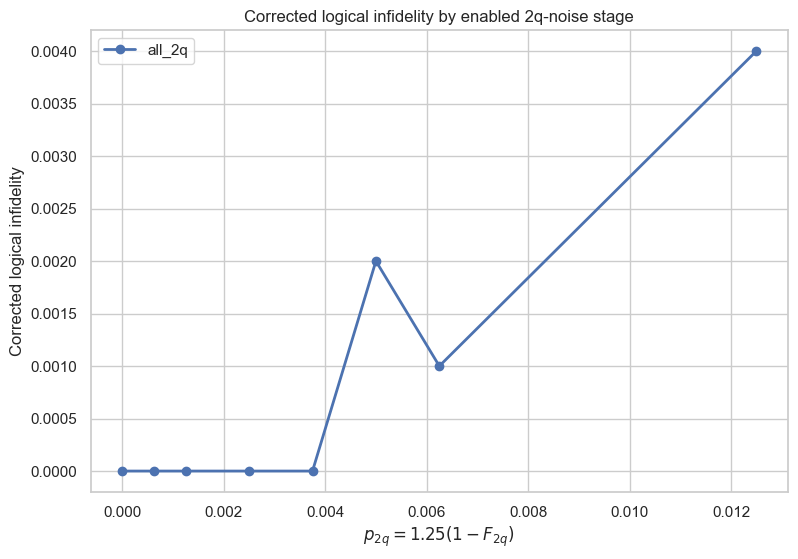

In [17]:
fig, ax = plt.subplots(figsize=(9, 6))

for label, group in summary_df.groupby("label"):
    group = group.sort_values("p_2q")
    ax.plot(
        group["p_2q"],
        group["corrected_infidelity"],
        marker="o",
        linewidth=2,
        label=label,
    )

ax.set_xlabel(r"$p_{2q} = 1.25(1 - F_{2q})$")
ax.set_ylabel("Corrected logical infidelity")
ax.set_title("Corrected logical infidelity by enabled 2q-noise stage")
ax.legend()
plt.show()


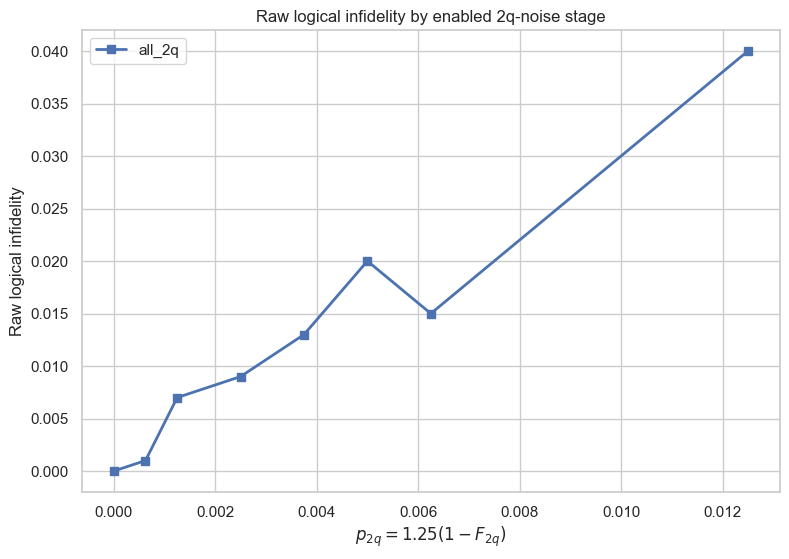

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

for label, group in summary_df.groupby("label"):
    group = group.sort_values("p_2q")
    ax.plot(
        group["p_2q"],
        group["raw_infidelity"],
        marker="s",
        linewidth=2,
        label=label,
    )

ax.set_xlabel(r"$p_{2q} = 1.25(1 - F_{2q})$")
ax.set_ylabel("Raw logical infidelity")
ax.set_title("Raw logical infidelity by enabled 2q-noise stage")
ax.legend()
plt.show()


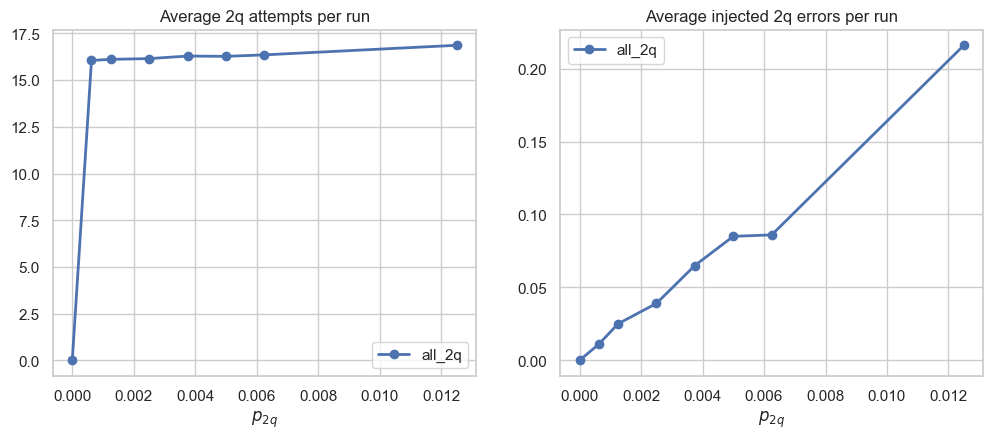

In [19]:
if {"avg_2q_attempts", "avg_2q_errors"}.issubset(summary_df.columns):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)

    for label, group in summary_df.groupby("label"):
        group = group.sort_values("p_2q")
        axes[0].plot(group["p_2q"], group["avg_2q_attempts"], marker="o", linewidth=2, label=label)
        axes[1].plot(group["p_2q"], group["avg_2q_errors"], marker="o", linewidth=2, label=label)

    axes[0].set_title("Average 2q attempts per run")
    axes[1].set_title("Average injected 2q errors per run")
    for axis in axes:
        axis.set_xlabel(r"$p_{2q}$")
        axis.legend()

    plt.show()
else:
    print("No 2q-noise summary rows were available for the selected cohorts.")


In [20]:
fit_rows = []
for label, group in summary_df.groupby("label"):
    raw_fit = fit_linear_quadratic(group, "raw_infidelity")
    corrected_fit = fit_linear_quadratic(group, "corrected_infidelity")
    fit_rows.append(
        {
            "label": label,
            "raw_A": raw_fit["A"],
            "raw_B": raw_fit["B"],
            "raw_rmse": raw_fit["rmse"],
            "corrected_A": corrected_fit["A"],
            "corrected_B": corrected_fit["B"],
            "corrected_rmse": corrected_fit["rmse"],
        }
    )

fit_df = pd.DataFrame(fit_rows).sort_values("label")
fit_df


,label,raw_A,raw_B,raw_rmse,corrected_A,corrected_B,corrected_rmse
0,all_2q,3.353141,-16.308639,0.002729,0.08649,18.91887,0.000502
